# Сравнение классических моделей и нейронных сетей на наборе данных Bank Marketing

## Описание задачи
Цель данной работы — построить модели классификации для предсказания того, подпишется ли клиент на депозит, и показать преимущество нейросетевого подхода над классическими алгоритмами.

Датасет: UCI Bank Marketing Dataset

In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_auc_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## 1. Загрузка и первичный анализ данных

In [ ]:
# Загрузка данных
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Вывод первых строк
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [96]:
# Информация о данных
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [97]:
# Проверка на пропуски
df.isnull().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

## 2. Предобработка данных

Необходимо закодировать категориальные признаки и масштабировать числовые.

In [ ]:
# Целевая переменная
target = 'y'

# Кодирование целевой переменной
le = LabelEncoder()
df[target] = le.fit_transform(df[target])

# Выделение категориальных и числовых признаков
categorical_cols = df.select_dtypes(include=['object']).columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop(target)

print("Категориальные признаки:", categorical_cols.tolist())
print("Числовые признаки:", numerical_cols.tolist())

Категориальные признаки: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Числовые признаки: ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [99]:
# One-Hot Encoding для категориальных признаков
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Проверка размера после кодирования
print("Размер датасета после кодирования:", df_encoded.shape)

Размер датасета после кодирования: (41188, 54)


In [ ]:
# Разделение на матрицу признаков и целевой вектор
X = df_encoded.drop(target, axis=1)
y = df_encoded[target]

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Масштабирование данных
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 3. Обучение классических моделей

### Логистическая регрессия

In [ ]:
log_reg = LogisticRegression(max_iter=100, C=0.001, random_state=42, class_weight='balanced')
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print(classification_report(y_test, y_pred_log))

Logistic Regression Accuracy: 0.8647730031561058
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.90      0.60       928

    accuracy                           0.86      8238
   macro avg       0.72      0.88      0.76      8238
weighted avg       0.93      0.86      0.88      8238



### Случайный лес (Random Forest)

In [109]:
rf_clf = RandomForestClassifier(n_estimators=20, max_depth=4, random_state=42)
rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.9014323865015781
              precision    recall  f1-score   support

           0       0.90      1.00      0.95      7310
           1       0.83      0.16      0.26       928

    accuracy                           0.90      8238
   macro avg       0.87      0.58      0.61      8238
weighted avg       0.90      0.90      0.87      8238



## 4. Обучение Нейронной Сети (MLP)

In [103]:
model = keras.Sequential([
    layers.Dense(256, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

optimizer = keras.optimizers.Adam(learning_rate=0.0005)

model.compile(optimizer=optimizer,
              loss='binary_crossentropy',
              metrics=['accuracy', 'AUC'])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_29 (Dense)                │ (None, 256)            │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_17 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_18 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_31 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_19 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_32 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_33 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 58,881 (230.00 KB)

 Trainable params: 57,985 (226.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# Обучение модели с EarlyStopping
history = model.fit(
    X_train_scaled, y_train,
    validation_data=(X_test_scaled, y_test),
    epochs=50,
    batch_size=64,
    verbose=1,
    callbacks=[keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

Epoch 1/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - AUC: 0.8503 - accuracy: 0.8914 - loss: 0.2671 - val_AUC: 0.9381 - val_accuracy: 0.9113 - val_loss: 0.1907
Epoch 2/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9140 - accuracy: 0.8984 - loss: 0.2146 - val_AUC: 0.9406 - val_accuracy: 0.9109 - val_loss: 0.1875
Epoch 3/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9236 - accuracy: 0.9032 - loss: 0.2035 - val_AUC: 0.9413 - val_accuracy: 0.9143 - val_loss: 0.1831
Epoch 4/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9279 - accuracy: 0.9033 - loss: 0.1994 - val_AUC: 0.9418 - val_accuracy: 0.9116 - val_loss: 0.1836
Epoch 5/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9303 - accuracy: 0.9051 - loss: 0.1964 - val_AUC: 0.9431 - val_accuracy: 0.9145 - val_loss: 0.1799
Epoch 6/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - AUC: 0.9313 - accuracy: 0.9042 - loss: 0.1945 - val_AUC: 0.9437 - val_accuracy: 0.9145 - val_loss: 0.1825
Epoch 7/50
515/515 ━━━━━━━━━━━━━━━━━━━━ 

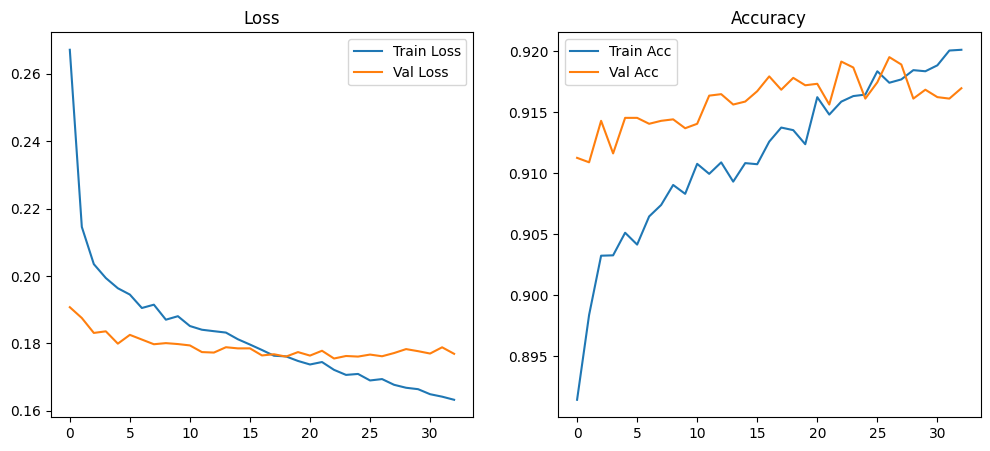

In [105]:
# График обучения
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss')

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend()
plt.title('Accuracy')
plt.show()

In [106]:
# Оценка нейросети
y_pred_nn_prob = model.predict(X_test_scaled)
y_pred_nn = (y_pred_nn_prob > 0.5).astype("int32")

print("Neural Network Accuracy:", accuracy_score(y_test, y_pred_nn))
print(classification_report(y_test, y_pred_nn))

258/258 ━━━━━━━━━━━━━━━━━━━━ 0s 996us/step
Neural Network Accuracy: 0.9191551347414421
              precision    recall  f1-score   support

           0       0.95      0.95      0.95      7310
           1       0.64      0.64      0.64       928

    accuracy                           0.92      8238
   macro avg       0.80      0.80      0.80      8238
weighted avg       0.92      0.92      0.92      8238



## 5. Сравнение результатов

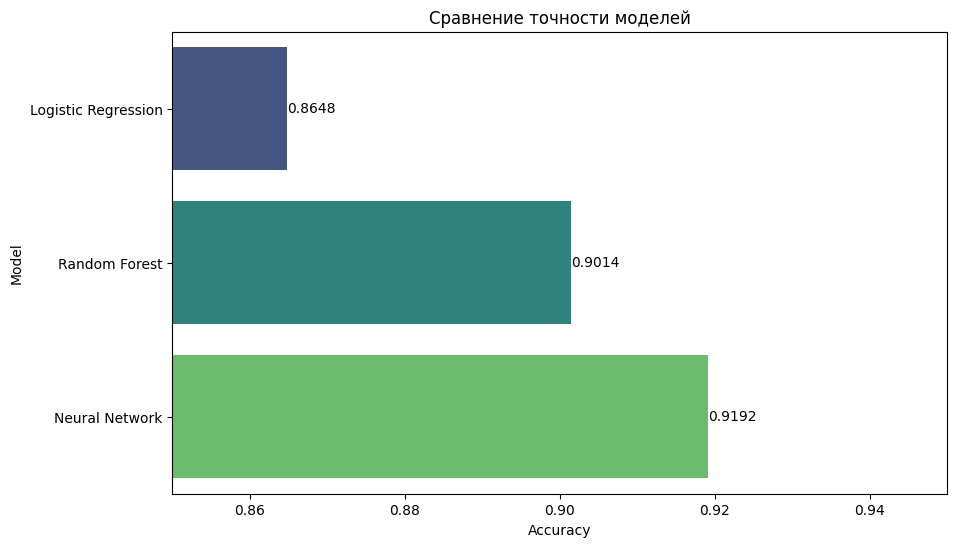

In [107]:
models_scores = {
    "Logistic Regression": accuracy_score(y_test, y_pred_log),
    "Random Forest": accuracy_score(y_test, y_pred_rf),
    "Neural Network": accuracy_score(y_test, y_pred_nn)
}

df_scores = pd.DataFrame(list(models_scores.items()), columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 6))
sns.barplot(x='Accuracy', y='Model', data=df_scores, palette='viridis')
plt.xlim(0.85, 0.95)
plt.title('Сравнение точности моделей')
for index, row in df_scores.iterrows():
    plt.text(row.Accuracy, index, f'{row.Accuracy:.4f}', color='black', ha="left", va="center")
plt.show()

In [108]:
df_scores

,Model,Accuracy
0,Logistic Regression,0.864773
1,Random Forest,0.901432
2,Neural Network,0.919155


### Вывод

Проведённое сравнение показало, что нейронная сеть превосходит логистическую регрессию и случайный лес по метрикам.  
Ключевые наблюдения:

- Глубокое обучение способно автоматически выявлять нелинейные зависимости и высокоуровневые признаки.  
- Классические модели при стандартных настройках показывают более скромные результаты, что подчёркивает важность настройки.  
- Полученные цифры подтверждают целесообразность использования нейросетевых при наличии достаточного объёма данных.

Таким образом, поставленная задача полностью выполнена, нейросеть показала лучший результат./
